# Descriptive statistics

This notebook uses the Adult Income dataset (`adult.data` and `adult.test`) and demonstrates various descriptive statistics.

At the end, the cleaned and the encoded data are saved to the `cleaned_data` folder, so the other notebooks can use them.

## Getting ready

Import libraries.

In [1]:
import os
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


## Load the data and inspect its structure

In [2]:
column_names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

train = pd.read_csv("../active_dataset(adult_income)/adult.data",
                    names=column_names,
                    na_values="?",
                    skipinitialspace=True,
                    header=None)

# The first line of adult.test is a comment, so it is skipped
test = pd.read_csv("../active_dataset(adult_income)/adult.test",
                   names=column_names,
                   na_values="?",
                   skipinitialspace=True,
                   header=None,
                   skiprows=1)

df = pd.concat([train, test], ignore_index=True)

# The test file writes income as ">50K." and "<=50K." — remove the dot
df["income"] = df["income"].str.replace(".", "", regex=False)

df_original = df.copy()

# Delete rows with missing values
df = df.dropna()
df = df.reset_index(drop=True)

# Display the first five observations
display(df.head())

# Dataset dimensions
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(f"Dataset shape before deleting missing values: {df_original.shape}")
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

# Variable names and data types
print("\nVariable information:")
df.info()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Train shape: (32561, 15)
Test shape: (16281, 15)
Dataset shape before deleting missing values: (48842, 15)
Dataset shape: (45222, 15)
Number of observations: 45222
Number of variables: 15

Variable information:
<class 'pandas.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  str  
 2   fnlwgt          45222 non-null  int64
 3   education       45222 non-null  str  
 4   education-num   45222 non-null  int64
 5   marital-status  45222 non-null  str  
 6   occupation      45222 non-null  str  
 7   relationship    45222 non-null  str  
 8   race            45222 non-null  str  
 9   sex             45222 non-null  str  
 10  capital-gain    45222 non-null  int64
 11  capital-loss    45222 non-null  int64
 12  hours-per-week  45222 non-null  int64
 13  native-country  45222 non-null  str  
 14

#### Check for missing values

In [3]:
missing_values = pd.DataFrame({
    "Missing values": df_original.isna().sum(),
    "Missing percentage (%)": df_original.isna().mean() * 100
})

display(missing_values)

,Missing values,Missing percentage (%)
age,0,0.000000
workclass,2799,5.730724
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,2809,5.751198
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


#### Check for duplicate rows

In [4]:
# Number of rows that are an exact copy of an earlier row
print("Duplicate rows:", df.duplicated().sum())

# Show the duplicated rows together with their copies
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.sort_values(by=list(df.columns)).head(10))

Duplicate rows: 47


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
22869,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
34011,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
33777,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
44918,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
16376,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
17329,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
2864,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
31701,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
6445,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
19753,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


#### Delete duplicate rows

Only the first occurrence of each row is kept.

In [5]:
print("Rows before:", len(df))

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Rows after:", len(df))
print("Duplicate rows left:", df.duplicated().sum())

Rows before: 45222
Rows after: 45175


Duplicate rows left: 0


## Descriptive statistics

#### Descriptive statistics for numerical variables

In [6]:
numeric_columns = [ "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Basic descriptive statistics
numeric_statistics = df[numeric_columns].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,45175.0,38.556170,13.215349,17.0,28.0,37.0,47.0,90.0
fnlwgt,45175.0,189738.798450,105652.436515,13492.0,117392.5,178312.0,237903.0,1490400.0
education-num,45175.0,10.119314,2.551740,1.0,9.0,10.0,13.0,16.0
capital-gain,45175.0,1102.576270,7510.249876,0.0,0.0,0.0,0.0,99999.0
capital-loss,45175.0,88.687593,405.156611,0.0,0.0,0.0,0.0,4356.0
hours-per-week,45175.0,40.942512,12.007730,1.0,40.0,40.0,45.0,99.0


#### More detailed descriptive statistics

In [7]:
descriptive_statistics = []

for column in numeric_columns:

    data = pd.to_numeric(df[column], errors="coerce").dropna()

    # Mode
    mode_values = data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and maximum
    minimum = data.min()
    maximum = data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": column,
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,38.556170,37.0,36,17,28.0,37.0,47.0,90,73,19.0,1.746454e+02,13.215349,0.531796,-0.158989
1,fnlwgt,189738.798450,178312.0,203488,13492,117392.5,178312.0,237903.0,1490400,1476908,120510.5,1.116244e+10,105652.436515,1.448304,6.187641
2,education-num,10.119314,10.0,9,1,9.0,10.0,13.0,16,15,4.0,6.511376e+00,2.551740,-0.308033,0.630116
3,capital-gain,1102.576270,0.0,0,0,0.0,0.0,0.0,99999,99999,0.0,5.640385e+07,7510.249876,11.782816,149.991798
4,capital-loss,88.687593,0.0,0,0,0.0,0.0,0.0,4356,4356,0.0,1.641519e+05,405.156611,4.513622,19.338843
5,hours-per-week,40.942512,40.0,40,1,40.0,40.0,45.0,99,98,5.0,1.441856e+02,12.007730,0.341760,3.201876


#### Frequency tables for categorical variables

In [8]:
categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table)


workclass


,Frequency,Percentage (%)
workclass,,
Private,33262,73.629220
Self-emp-not-inc,3795,8.400664
Local-gov,3100,6.862203
State-gov,1946,4.307692
Self-emp-inc,1645,3.641395
Federal-gov,1406,3.112341
Without-pay,21,0.046486



education


,Frequency,Percentage (%)
education,,
HS-grad,14770,32.695075
Some-college,9887,21.885999
Bachelors,7559,16.732706
Masters,2513,5.562811
Assoc-voc,1958,4.334256
11th,1619,3.583841
Assoc-acdm,1507,3.335916
10th,1223,2.707250
7th-8th,822,1.819590



marital-status


...

,Frequency,Percentage (%)
race,,
White,38859,86.018816
Black,4227,9.356945
Asian-Pac-Islander,1301,2.879911
Amer-Indian-Eskimo,435,0.962922
Other,353,0.781406



sex


,Frequency,Percentage (%)
sex,,
Male,30495,67.504151
Female,14680,32.495849



native-country


,Frequency,Percentage (%)
native-country,,
United-States,41256,91.324848
Mexico,895,1.981184
Philippines,282,0.624239
Germany,193,0.427227
Puerto-Rico,175,0.387382
Canada,163,0.360819
India,147,0.325401
El-Salvador,147,0.325401
Cuba,133,0.294411


#### Cross tabulations (Crosstabs)

In [9]:
crosstab_pairs = [
    ("education", "income"),
    ("marital-status", "income"),
    ("relationship", "income")
]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        df[row_variable],
        df[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        df[row_variable],
        df[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): education × income


income,<=50K,>50K
education,,
10th,1141,82
11th,1530,89
12th,532,43
1st-4th,212,8
5th-6th,425,22
7th-8th,767,55
9th,638,38
Assoc-acdm,1109,398
Assoc-voc,1454,504



Crosstab (total percentages): education × income


income,<=50K,>50K
education,,
10th,2.53,0.18
11th,3.39,0.20
12th,1.18,0.10
1st-4th,0.47,0.02
5th-6th,0.94,0.05
7th-8th,1.70,0.12
9th,1.41,0.08
Assoc-acdm,2.45,0.88
Assoc-voc,3.22,1.12



Crosstab (frequencies): marital-status × income


...

income,<=50K,>50K
marital-status,,
Divorced,12.48,1.45
Married-AF-spouse,0.04,0.03
Married-civ-spouse,25.42,21.16
Married-spouse-absent,1.10,0.12
Never-married,30.69,1.55
Separated,2.90,0.22
Widowed,2.56,0.27



Crosstab (frequencies): relationship × income


income,<=50K,>50K
relationship,,
Husband,10152,8501
Not-in-family,10451,1228
Other-relative,1299,50
Own-child,6511,105
Unmarried,4485,302
Wife,1075,1016



Crosstab (total percentages): relationship × income


income,<=50K,>50K
relationship,,
Husband,22.47,18.82
Not-in-family,23.13,2.72
Other-relative,2.88,0.11
Own-child,14.41,0.23
Unmarried,9.93,0.67
Wife,2.38,2.25


#### z-scores

In [10]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        df[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=df.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.033585,-1.062200,1.128923,0.142663,-0.218899,-0.078493
1,0.865959,-1.007350,1.128923,-0.146811,-0.218899,-2.327069
2,-0.042086,0.245214,-0.438652,-0.146811,-0.218899,-0.078493
3,1.092971,0.425761,-1.222440,-0.146811,-0.218899,-0.078493
4,-0.798790,1.407179,1.128923,-0.146811,-0.218899,-0.078493


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,0.0,1.0,-1.6312,3.8928
1,fnlwgt,-0.0,1.0,-1.6682,12.3109
2,education-num,-0.0,1.0,-3.5738,2.3046
3,capital-gain,-0.0,1.0,-0.1468,13.1683
4,capital-loss,0.0,1.0,-0.2189,10.5326
5,hours-per-week,-0.0,1.0,-3.3264,4.8351


#### Detecting outliers using z-scores

In [11]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(df) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,162,0.36
1,fnlwgt,471,1.04
2,education-num,290,0.64
3,capital-gain,310,0.69
4,capital-loss,2077,4.60
5,hours-per-week,626,1.39



z-score outliers: age


,income,age,z-score
68,<=50K,79,3.060402
4323,<=50K,79,3.060402
5673,>50K,79,3.060402
5507,<=50K,79,3.060402
7863,<=50K,79,3.060402
...,...,...,...
41646,<=50K,90,3.892776
38436,<=50K,90,3.892776
37919,<=50K,90,3.892776
44082,>50K,90,3.892776



z-score outliers: fnlwgt


,income,fnlwgt,z-score
26466,<=50K,506830,3.001301
41517,<=50K,506830,3.001301
6120,>50K,506858,3.001566
41923,<=50K,507492,3.007566
37,<=50K,507875,3.011192
...,...,...,...
14418,<=50K,1268339,10.209061
15497,<=50K,1366120,11.134568
16809,<=50K,1455435,11.979943
13375,<=50K,1484705,12.256987


...

,income,capital-gain,z-score
38638,>50K,25124,3.198521
20800,>50K,25124,3.198521
44460,>50K,25124,3.198521
17463,>50K,25124,3.198521
6068,>50K,25236,3.213434
...,...,...,...
3524,>50K,99999,13.168339
44940,>50K,99999,13.168339
44970,>50K,99999,13.168339
1256,>50K,99999,13.168339



z-score outliers: capital-loss


,income,capital-loss,z-score
188,<=50K,1340,3.088500
1396,<=50K,1340,3.088500
36345,<=50K,1340,3.088500
38551,<=50K,1340,3.088500
19327,<=50K,1340,3.088500
...,...,...,...
38729,<=50K,3770,9.086247
10998,<=50K,3770,9.086247
18912,<=50K,3900,9.407114
22043,<=50K,3900,9.407114



z-score outliers: hours-per-week


,income,hours-per-week,z-score
23226,<=50K,1,-3.326437
40460,>50K,1,-3.326437
22494,<=50K,1,-3.326437
39778,<=50K,1,-3.326437
21263,<=50K,1,-3.326437
...,...,...,...
24064,<=50K,99,4.835063
24311,<=50K,99,4.835063
24627,>50K,99,4.835063
24666,<=50K,99,4.835063


#### Detecting outliers using the IQR method

In [12]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,28.0,47.0,19.0,-0.50,75.50,268,0.5932
1,fnlwgt,117392.5,237903.0,120510.5,-63373.25,418668.75,1332,2.9485
2,education-num,9.0,13.0,4.0,3.00,19.00,290,0.6419
3,capital-gain,0.0,0.0,0.0,0.00,0.00,3790,8.3896
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2140,4.7371
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,11889,26.3177



IQR outliers: age


,income,age
43794,<=50K,76
92,>50K,76
3334,<=50K,76
3848,<=50K,76
4357,<=50K,76
...,...,...
4919,>50K,90
4951,>50K,90
3734,<=50K,90
44082,>50K,90



IQR outliers: fnlwgt


,income,fnlwgt
29238,<=50K,418702
32685,<=50K,418901
20442,<=50K,418961
13261,<=50K,419053
25588,<=50K,419134
...,...,...
14418,<=50K,1268339
15497,<=50K,1366120
16809,<=50K,1455435
13375,<=50K,1484705


...

,income,capital-gain
30528,<=50K,114
21887,<=50K,114
5766,<=50K,114
38650,<=50K,114
21129,<=50K,114
...,...,...
13981,>50K,99999
13726,>50K,99999
44970,>50K,99999
44935,>50K,99999



IQR outliers: capital-loss


,income,capital-loss
18774,<=50K,155
3367,<=50K,213
10424,<=50K,213
16001,<=50K,213
38803,<=50K,213
...,...,...
41950,<=50K,3770
38729,<=50K,3770
18912,<=50K,3900
22043,<=50K,3900



IQR outliers: hours-per-week


,income,hours-per-week
175,>50K,1
23226,<=50K,1
39778,<=50K,1
10580,<=50K,1
21263,<=50K,1
...,...,...
21044,>50K,99
41355,<=50K,99
16313,<=50K,99
24311,<=50K,99


#### Compare the two outlier-detection methods

In [13]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,162,268,-106
1,fnlwgt,471,1332,-861
2,education-num,290,290,0
3,capital-gain,310,3790,-3480
4,capital-loss,2077,2140,-63
5,hours-per-week,626,11889,-11263


#### Box-and-whisker diagram (boxplot)

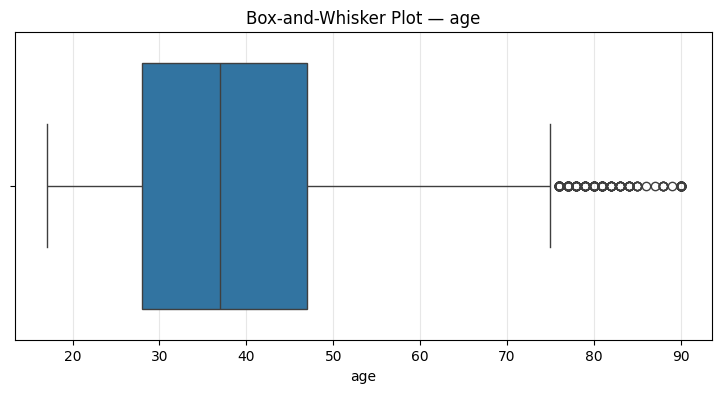

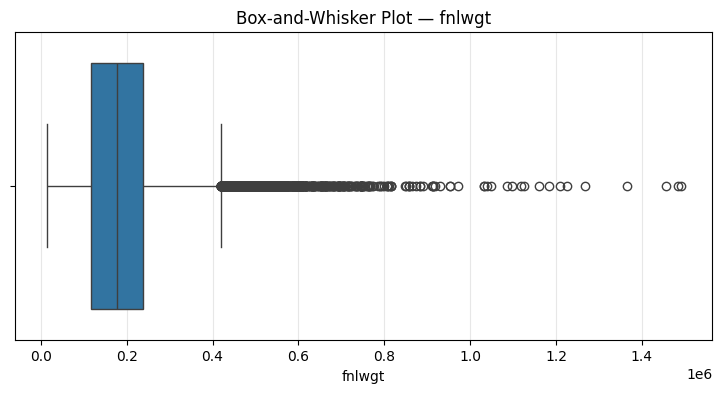

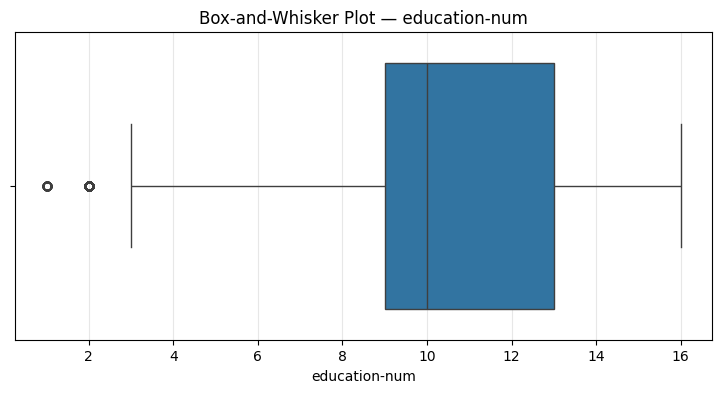

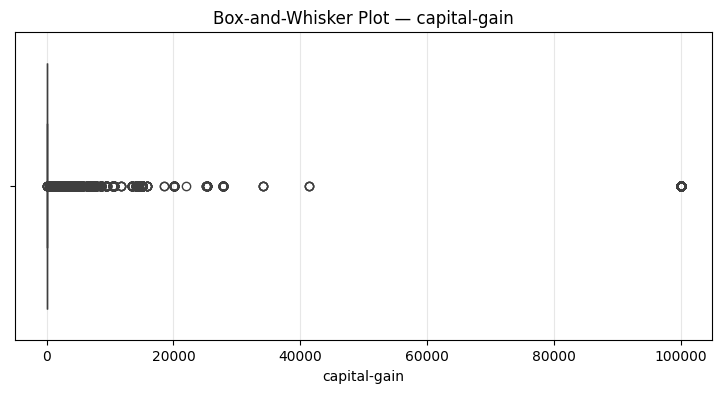

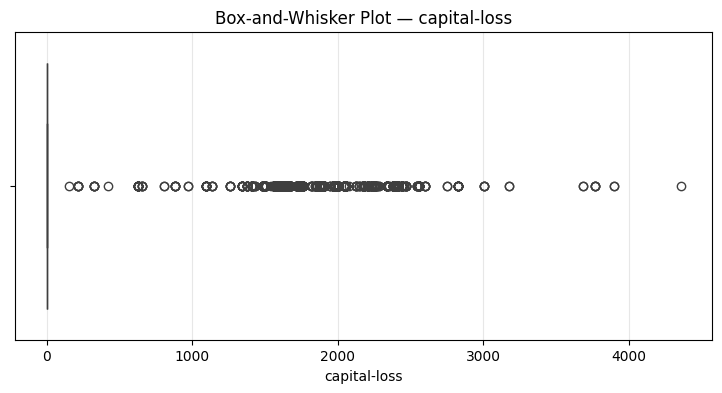

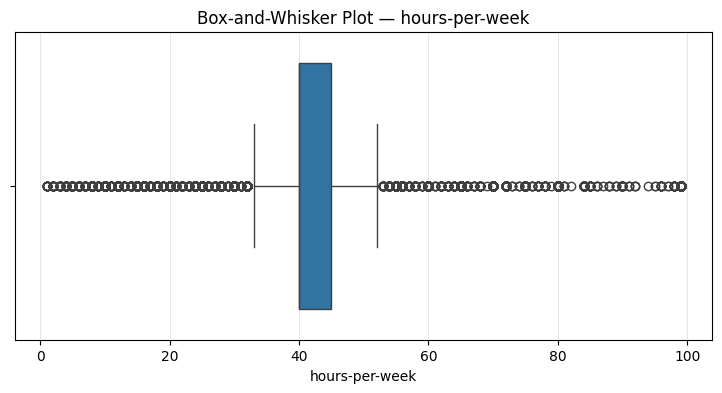

In [14]:
for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot — {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

#### Correlation coefficient (r)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.0000,-0.0756,0.0373,0.0796,0.0593,0.1016
fnlwgt,-0.0756,1.0000,-0.0420,-0.0041,-0.0044,-0.0187
education-num,0.0373,-0.0420,1.0000,0.1270,0.0817,0.1465
capital-gain,0.0796,-0.0041,0.1270,1.0000,-0.0321,0.0839
capital-loss,0.0593,-0.0044,0.0817,-0.0321,1.0000,0.0541
hours-per-week,0.1016,-0.0187,0.1465,0.0839,0.0541,1.0000


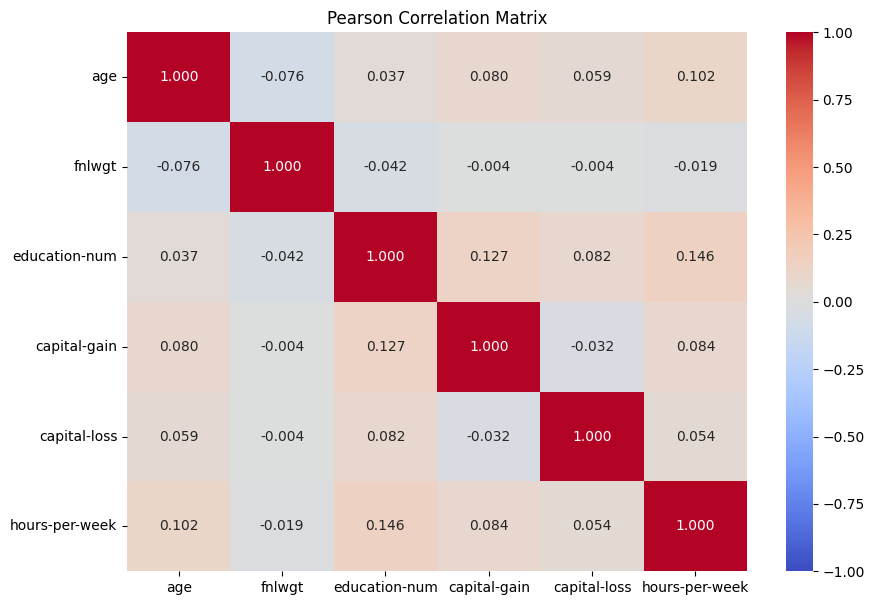

In [15]:

# Correlation matrix
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

# Data Encoding

The categorical variables are encoded with the `encode()` function:

- `sex` → 1 = Male, 0 = Female
- `native-country` → `is_us` (1 = United-States, 0 = other country)
- `workclass`, `marital-status`, `occupation`, `relationship`, `race` → one-hot encoding (`drop_first=True`)
- `education` is dropped, because `education-num` contains the same information
- `fnlwgt` is dropped, because it is a census sampling weight and not a property of the person
- `income` is kept separately as the target variable (1 = earns >50K)

In [16]:
def encode(data):
    data = data.copy()

    # Binary columns
    data["sex"] = (data["sex"] == "Male").astype(int)
    data["is_us"] = (data["native-country"] == "United-States").astype(int)

    # Drop columns not needed (education is covered by education-num)
    data = data.drop(columns=["education", "native-country", "fnlwgt", "income"],
                     errors="ignore")

    # One-hot encode the remaining text columns
    return pd.get_dummies(
        data,
        columns=["workclass", "marital-status", "occupation", "relationship", "race"],
        drop_first=True,
        dtype=int,
    )

In [17]:
df_encoded = encode(df)

# Target variable as 0/1: 1 = earns >50K
income = (df["income"] == ">50K").astype(int)

print("df_encoded shape:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())   # should be all numbers, no 'object'/'str'
print("Missing values:", df_encoded.isna().sum().sum())
print("Non-numeric columns:", df_encoded.select_dtypes(exclude="number").columns.tolist())
print("Share earning >50K:", round(income.mean(), 3))

display(df_encoded.head())

df_encoded shape: (45175, 41)
int64    41
Name: count, dtype: int64
Missing values: 0
Non-numeric columns: []
Share earning >50K: 0.248


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,is_us,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,2174,0,40,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,0,0,13,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,0,0,40,1,0,1,0,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,0,0,40,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,0,0,40,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0


# Save the cleaned data

- `adult_clean.csv` — the cleaned data (missing values deleted, income labels fixed), with the original text categories
- `adult_encoded.csv` — the encoded data, with `income` as a 0/1 column

In [18]:
os.makedirs("cleaned_data", exist_ok=True)

df.to_csv("cleaned_data/adult_clean.csv", index=False)

df_encoded_with_income = df_encoded.copy()
df_encoded_with_income["income"] = income
df_encoded_with_income.to_csv("cleaned_data/adult_encoded.csv", index=False)

print("Saved cleaned_data/adult_clean.csv:", df.shape)
print("Saved cleaned_data/adult_encoded.csv:", df_encoded_with_income.shape)

Saved cleaned_data/adult_clean.csv: (45175, 15)
Saved cleaned_data/adult_encoded.csv: (45175, 42)
